In [1]:
from pathlib import Path
from pynq import Overlay

assert Path("ecg_filter.bit").is_file(), "BIT file missing"
assert Path("ecg_filter.hwh").is_file(), "HWH file missing"

overlay = Overlay("ecg_filter.bit")

print("Overlay loaded:", overlay.is_loaded())
print("Available IPs:", list(overlay.ip_dict))

Overlay loaded: True
Available IPs: ['axi_dma_0']


In [2]:
import numpy as np
import time
from pynq import allocate

dma = overlay.axi_dma_0

FS = 360
N = 2048
t = np.arange(N) / FS

# Test input: 5 Hz signal plus 50 Hz interference
raw_signal = (
    np.sin(2 * np.pi * 5 * t)
    + 0.5 * np.sin(2 * np.pi * 50 * t)
)

# Encode as signed Q4.12
encoded = np.rint(raw_signal * 4096)
assert encoded.min() >= -32768 and encoded.max() <= 32767

in_buf = allocate(shape=(N,), dtype=np.int16)
out_buf = allocate(shape=(N,), dtype=np.int16)

in_buf[:] = encoded.astype(np.int16)
out_buf[:] = 0
in_buf.flush()
out_buf.flush()

# Prepare the receiver before sending data
dma.recvchannel.transfer(out_buf)
dma.sendchannel.transfer(in_buf)

# Check completion with a 10-second timeout
deadline = time.monotonic() + 10

while True:
    tx_status = dma.mmio.read(0x04)
    rx_status = dma.mmio.read(0x34)

    if (tx_status | rx_status) & 0x70:
        raise RuntimeError(
            f"DMA error: TX={tx_status:#010x}, RX={rx_status:#010x}"
        )

    if dma.sendchannel.idle and dma.recvchannel.idle:
        break

    if time.monotonic() > deadline:
        raise TimeoutError(
            f"DMA timeout: TX={tx_status:#010x}, RX={rx_status:#010x}"
        )

    time.sleep(0.001)

dma.sendchannel.wait()
dma.recvchannel.wait()
out_buf.invalidate()

filtered = np.array(out_buf, dtype=np.int16) / 4096.0

print("DMA transfer completed.")
print("Samples sent:", N)
print("Nonzero output samples:", np.count_nonzero(out_buf))
print("First 20 output values:", filtered[:20])

DMA transfer completed.
Samples sent: 2048
Nonzero output samples: 2046
First 20 output values: [ 0.          0.         -0.00024414 -0.00073242 -0.00097656 -0.00146484
 -0.0012207  -0.00073242 -0.00048828 -0.00073242 -0.00146484 -0.00268555
 -0.00390625 -0.00463867 -0.00439453 -0.00390625 -0.00317383 -0.00317383
 -0.00390625 -0.00585938]


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(t[:540], raw_signal[:540], label="Input: 5 Hz + 50 Hz")
plt.plot(t[:540], filtered[:540], label="FPGA FIR output")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("PYNQ-Z2: Hardware FIR Filtering")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

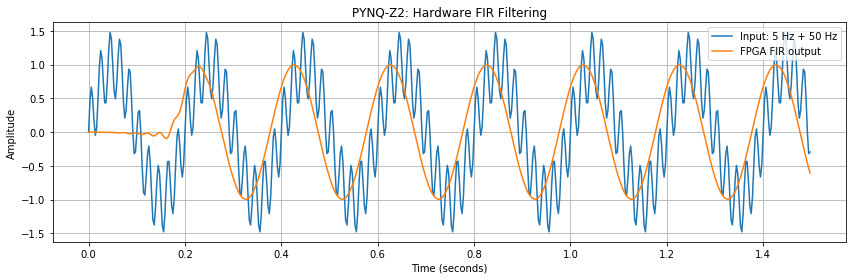

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(t[:540], raw_signal[:540], label="Input: 5 Hz + 50 Hz")
plt.plot(t[:540], filtered[:540], label="FPGA FIR output")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("PYNQ-Z2: Hardware FIR Filtering")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()